<a href="https://colab.research.google.com/github/Maxxx-VS/IMA_SibADI/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_2_6_books.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Books



In [1]:
!pip install --upgrade patsy statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [3]:
# Загрузка данных
df = pd.read_csv('book_sales.csv')
y = df['Hardcover'].values
t = np.arange(1, len(y) + 1)

In [4]:
# Линейная модель тренда
X = sm.add_constant(t)
model = sm.OLS(y, X).fit()
a, b = model.params[1], model.params[0]
y_pred = model.predict(X)
residuals = y - y_pred

In [5]:
# Скользящая средняя (окно 3)
sma = df['Hardcover'].rolling(window=3).mean()

In [7]:
# Расчет характеристик адекватности
r2 = model.rsquared
mean_res = np.mean(residuals)
dw = durbin_watson(residuals)

# Критерий RS
rs_stat = (np.max(residuals) - np.min(residuals)) / np.std(residuals, ddof=1)

print(f"Результаты моделирования")
print(f"Уравнение тренда: y = {a:.4f} * t + {b:.4f}")
print(f"R-квадрат: {r2:.4f}")
print(f"\n1. Мат. ожидание остатков: {mean_res:.4e} (Адекватна, если близко к 0)")
print(f"3. Статистика Дарбина-Уотсона: {dw:.4f} (Адекватна, если ~2)")
print(f"4. Критерий RS: {rs_stat:.4f} (Границы [3.47; 4.89])")

Результаты моделирования
Уравнение тренда: y = 3.3306 * t + 147.2092
R-квадрат: 0.5293

1. Мат. ожидание остатков: -1.5158e-14 (Адекватна, если близко к 0)
3. Статистика Дарбина-Уотсона: 2.0524 (Адекватна, если ~2)
4. Критерий RS: 3.4367 (Границы [3.47; 4.89])


In [9]:
# Прогноз на 1 и 2 шага вперед
t_next = np.array([len(y) + 1, len(y) + 2])
X_next = sm.add_constant(t_next, has_constant='add')
# Для прогноза на новых данных нужно подстроить X_next под структуру модели
forecast = model.predict([ [1, t_next[0]], [1, t_next[1]] ])

# Интервальный прогноз (90% доверие, t-критерий для n=30 ≈ 1.699)
se = np.sqrt(model.mse_resid) # Стандартная ошибка регрессии
t_crit = stats.t.ppf(0.95, df=len(y)-2) # Односторонний 95% для получения 90% интервала
margin = t_crit * se * np.sqrt(1 + 1/len(y)) # Упрощенная формула интервала

print(f"Прогноз")
print(f"Прогноз на шаг t+1: {forecast[0]:.2f} ± {margin:.2f}")
print(f"Прогноз на шаг t+2: {forecast[1]:.2f}")

Прогноз
Прогноз на шаг t+1: 250.46 ± 48.66
Прогноз на шаг t+2: 253.79


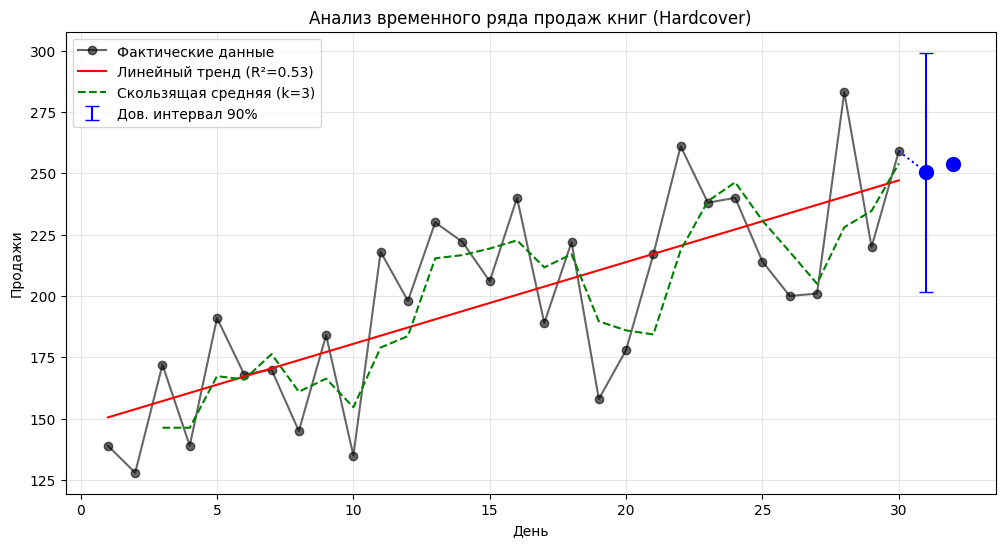

In [10]:
# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(t, y, 'ko-', label='Фактические данные', alpha=0.6)
plt.plot(t, y_pred, 'r-', label=f'Линейный тренд (R²={r2:.2f})')
plt.plot(t, sma, 'g--', label='Скользящая средняя (k=3)')

# Отрисовка прогноза
plt.scatter(t_next, forecast, color='blue', s=100, zorder=5)
plt.plot([t[-1], t_next[0]], [y[-1], forecast[0]], 'b:')
plt.errorbar(t_next[0], forecast[0], yerr=margin, fmt='none', ecolor='blue', capsize=5, label='Дов. интервал 90%')

plt.title('Анализ временного ряда продаж книг (Hardcover)')
plt.xlabel('День')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()